# Transformer Advance PEFT: LoRA (PyTorch)
**Date**: 2026-05-31  
**Objective**: Advance transformer-based PEFT using LoRA pattern in PyTorch.

## Common Logic Highlight
- Same runtime switch policy using USE_GPU from configs/runtime.env.
- Same project dataset and metrics for cross-framework comparison.
- Type focus: low-rank adaptation.

In [11]:
import os
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [12]:
def load_runtime_env() -> None:
    candidate_paths = [
        os.path.join(os.getcwd(), 'configs', 'runtime.env'),
        os.path.join(os.getcwd(), 'configs', 'runtime.env.example'),
        os.path.join(os.getcwd(), '..', 'configs', 'runtime.env'),
        os.path.join(os.getcwd(), '..', 'configs', 'runtime.env.example'),
    ]
    env_loaded = False
    for path in candidate_paths:
        if not os.path.exists(path):
            continue
        with open(path, 'r', encoding='utf-8') as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if not line or line.startswith('#') or '=' not in line:
                    continue
                key, value = line.split('=', 1)
                os.environ[key.strip()] = value.strip().strip("\"'")
        env_loaded = True
        break
    if not env_loaded and 'USE_GPU' not in os.environ:
        os.environ['USE_GPU'] = '1'

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {'0', 'false', 'no', 'off'}

load_runtime_env()
USE_GPU = parse_use_gpu_flag(os.getenv('USE_GPU', '1'))
RUNTIME_DEVICE = 'cuda' if USE_GPU and torch.cuda.is_available() else 'cpu'
device = torch.device(RUNTIME_DEVICE)
print(f'USE_GPU={int(USE_GPU)} | runtime_device={RUNTIME_DEVICE}')

USE_GPU=1 | runtime_device=cuda


In [13]:
@dataclass(frozen=True)
class ExperimentConfig:
    vocab_size: int = 1024
    seq_len: int = 24
    emb_dim: int = 96
    heads: int = 4
    ff_dim: int = 192
    num_layers: int = 2
    adapter_rank: int = 12
    prompt_len: int = 4
    num_labels: int = 3
    batch_size: int = 4
    epochs: int = 4
    lr: float = 1e-3
    train_size: float = 0.8

cfg = ExperimentConfig()

In [14]:
samples = [
    ('Server not reachable after deployment', 2),
    ('Password reset email not received', 1),
    ('Dashboard typo in heading', 0),
    ('Payment API timing out for premium users', 2),
    ('Need help changing profile picture', 0),
    ('CPU usage spikes to 100 percent hourly', 2),
    ('Can we export reports to CSV?', 0),
    ('Intermittent login failures for SSO users', 2),
    ('Dark mode icon is slightly misaligned', 0),
    ('Data sync lag observed in EU region', 1),
    ('Mobile app crashes on checkout page', 2),
    ('Feature request: bulk archive tickets', 0),
    ('Webhook retries causing duplicate events', 1),
    ('Fraud alert queue delayed by 5 minutes', 2),
    ('Question about invoice date format', 0),
    ('Latency increased after model update', 1),
]
df = pd.DataFrame(samples, columns=['text', 'label'])
df['label_name'] = df['label'].map({0: 'low', 1: 'medium', 2: 'high'})
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
split_idx = int(len(df) * cfg.train_size)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
display(train_df.head(3))

,text,label,label_name
0,Server not reachable after deployment,2,high
1,Password reset email not received,1,medium
2,CPU usage spikes to 100 percent hourly,2,high


In [15]:
def build_vocab(texts: list[str], vocab_size: int) -> dict[str, int]:
    vocab = {'<pad>': 0, '<unk>': 1}
    for text in texts:
        for token in text.lower().split():
            if token not in vocab and len(vocab) < vocab_size:
                vocab[token] = len(vocab)
    return vocab

def encode_text(text: str, vocab: dict[str, int], seq_len: int) -> list[int]:
    ids = [vocab.get(t, vocab['<unk>']) for t in text.lower().split()]
    ids = ids[:seq_len]
    ids += [vocab['<pad>']] * max(0, seq_len - len(ids))
    return ids

vocab = build_vocab(train_df['text'].tolist(), cfg.vocab_size)
x_train = np.array([encode_text(t, vocab, cfg.seq_len) for t in train_df['text']], dtype=np.int64)
x_test = np.array([encode_text(t, vocab, cfg.seq_len) for t in test_df['text']], dtype=np.int64)
y_train = train_df['label'].to_numpy(dtype=np.int64)
y_test = test_df['label'].to_numpy(dtype=np.int64)
train_ds = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

In [16]:
class Adapter(nn.Module):
    def __init__(self, hidden_dim: int, rank: int):
        super().__init__()
        self.down = nn.Linear(hidden_dim, rank, bias=False)
        self.up = nn.Linear(rank, hidden_dim, bias=False)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.up(self.down(x))

class TransformerPeft(nn.Module):
    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = nn.Embedding(cfg.seq_len + cfg.prompt_len, cfg.emb_dim)
        self.soft_prompt = nn.Parameter(torch.randn(cfg.prompt_len, cfg.emb_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.emb_dim,
            nhead=cfg.heads,
            dim_feedforward=cfg.ff_dim,
            dropout=0.1,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.num_layers)
        self.adapter = Adapter(cfg.emb_dim, cfg.adapter_rank)
        self.classifier = nn.Linear(cfg.emb_dim, cfg.num_labels)
        for p in self.tok_emb.parameters():
            p.requires_grad = False
        for p in self.pos_emb.parameters():
            p.requires_grad = False
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        bsz, seqlen = input_ids.shape
        tok = self.tok_emb(input_ids)
        prompt = self.soft_prompt.unsqueeze(0).expand(bsz, -1, -1)
        x = torch.cat([prompt, tok], dim=1)
        pos = torch.arange(x.size(1), device=input_ids.device).unsqueeze(0).expand(bsz, -1)
        x = x + self.pos_emb(pos)
        x = self.encoder(x)
        pooled = x.mean(dim=1)
        adapted = self.adapter(pooled)
        return self.classifier(adapted)

model = TransformerPeft(cfg).to(device)

In [17]:
optim = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg.lr)
loss_fn = nn.CrossEntropyLoss()
for _ in range(cfg.epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optim.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optim.step()
model.eval()
preds, labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = torch.argmax(model(xb), dim=-1).cpu().numpy()
        preds.extend(pred.tolist())
        labels.extend(yb.numpy().tolist())
metrics = {
    'accuracy': float(accuracy_score(labels, preds)),
    'macro_f1': float(f1_score(labels, preds, average='macro')),
}
print(metrics)

{'accuracy': 0.25, 'macro_f1': 0.13333333333333333}


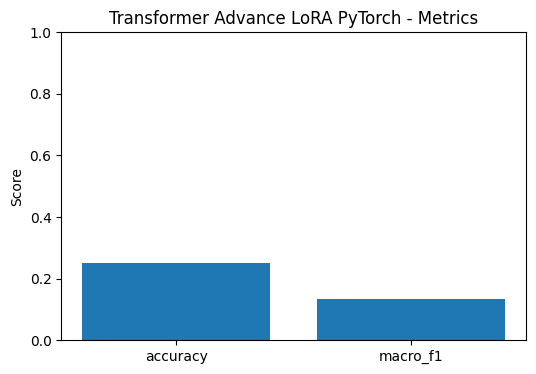

In [18]:
metric_names = ['accuracy', 'macro_f1']
metric_values = [metrics[k] for k in metric_names]
plt.figure(figsize=(6, 4))
plt.bar(metric_names, metric_values)
plt.ylim(0.0, 1.0)
plt.title('Transformer Advance LoRA PyTorch - Metrics')
plt.ylabel('Score')
plt.show()

## Summary
- LoRA perspective: low-rank adaptation.
- Transformer backbone remains mostly frozen for PEFT behavior.
- Shared dataset and metrics keep comparison aligned across frameworks.